## GymVibe: гибридная контекстная рекомендательная система

Система подбора музыки для тренировок, которая адаптируется под текущую интенсивность (аудио-архетипы) и персональный темп пользователя.

Архитектура: Two-Stage Recommender System.

1. **Retrieval (L0):** двухбашенная нейросеть (Two-Tower / DSSM) на PyTorch ищет кандидатов по векторной близости пользователя и трека.
2. **Ranking (L1):** CatBoost с функцией потерь YetiRank переранжирует кандидатов с учётом контекста тренировки.

Датасет содержит каталог песен, а не реальные события. Поэтому ниже создаются синтетические implicit-feedback логи, NDCG@5 — метрика этого воспроизводимого офлайн-эксперимента.

### Настройки и импорт

In [1]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00


In [2]:
from __future__ import annotations
import warnings

import random
import re
from dataclasses import dataclass
from typing import Iterable

import numpy as np
import pandas as pd
import torch
from matplotlib import pyplot as plt
import seaborn as sns
from catboost import CatBoostRanker, Pool
from sklearn.metrics import ndcg_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.nn import functional as F

warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

SEED = 42
VIBE_LABELS = [
    "Boss Fight / Doom Slayer", "Zen / Lo-Fi Recovery",
    "Golden Era (Old School)", "Pilates Girl", "Pure Rage / Metalhead",
    "Sigma Grindset", "Пацанский Вайб",
]
ITEM_FEATURES = [
    "bpm", "gain", "street_score", "lyrics_word_count", "power_index", "word_density",
]
RANK_FEATURES = ITEM_FEATURES + ["context", "genre_final", "user_pref_bpm", "nn_score"]


def seed_everything(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

### 1. Feature Engineering & Preprocessing

- Акустические признаки
- **Power Index:** соотношение темпа и громкости (энергетика трека).
- **Street Score:** счётчик уличных маркеров в тексте.
- **Word Density:** плотность текста относительно длительности.


In [3]:
class FeatureProcessor:
    def __init__(self) -> None:
        self.item_scaler = StandardScaler()
        self.bpm_scaler = StandardScaler()
        self.fitted = False

    @staticmethod
    def add_features(df: pd.DataFrame) -> pd.DataFrame:
        result = df.copy()

        lyrics = result["clean_lyrics"].fillna("").astype(str).str.lower()
        lyrics = lyrics.str.replace(r"\[.*?\]", "", regex=True)
        street_words = ["street", "block", "gang", "money", "hustle", "choppa", "glock"]
        result["street_score"] = sum(lyrics.str.count(word) for word in street_words)
        duration_sec = pd.to_numeric(result["itunes_duration_ms"], errors="coerce").fillna(0) / 1000
        result["word_density"] = result["lyrics_word_count"].fillna(0) / (duration_sec + 1)

        result["power_index"] = result["bpm"].fillna(0) * (result["gain"].fillna(-10) + 25) / 100

        return result

    def fit(self, df: pd.DataFrame) -> "FeatureProcessor":
        enriched = self.add_features(df)
        self.item_scaler.fit(enriched[ITEM_FEATURES].fillna(0))
        self.bpm_scaler.fit(enriched[["bpm"]].fillna(0))
        self.fitted = True
        return self

    def transform_items(self, df: pd.DataFrame) -> pd.DataFrame:
        if not self.fitted:
            raise RuntimeError("FeatureProcessor must be fitted before transformation")

        result = self.add_features(df)
        result[ITEM_FEATURES] = self.item_scaler.transform(result[ITEM_FEATURES].fillna(0))
        return result

    def transform_preference(self, bpm) -> np.ndarray:
        bpm_values = np.atleast_1d(bpm).astype("float32")
        values = pd.DataFrame({"bpm": bpm_values})
        return self.bpm_scaler.transform(values.fillna(0)).astype("float32")

### 2. Retrieval Layer (Two-Tower Neural Network)

User Tower получает нормализованный preferred BPM и one-hot контекст тренировки. Item Tower получает engineered-признаки трека. Положительные пары обучаются с in-batch negatives.

In [4]:
class Tower(nn.Module):
    def __init__(self, input_dim: int, embedding_dim: int) -> None:
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, embedding_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return F.normalize(self.network(x), dim=1)


class TwoTowerModel(nn.Module):
    def __init__(self, user_input_dim: int, item_input_dim: int, embedding_dim: int = 64) -> None:
        super().__init__()
        self.user_tower = Tower(user_input_dim, embedding_dim)
        self.item_tower = Tower(item_input_dim, embedding_dim)

    def forward(self, u: torch.Tensor, i: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        return self.user_tower(u), self.item_tower(i)

### 3. Ranking Layer (CatBoost YetiRank)

Retrieval возвращает top-K кандидатов. Затем CatBoostRanker с YetiRank использует neural score, контекст, жанр, preferred BPM и признаки трека. Группа ранжирования — сессия показа.

In [5]:
def generate_interactions(catalogue, n_users=200,
                          sessions_per_user=4, tracks_per_session=20,
                          seed=SEED):
    catalogue = catalogue.drop_duplicates("track_name").copy()
    rng = np.random.default_rng(seed)
    rows = []
    bpm = catalogue["bpm"].fillna(catalogue["bpm"].median())

    hidden_prefs = {}
    for uid in range(n_users):
        hidden_prefs[uid] = float(np.clip(
            rng.normal(bpm.median(), bpm.std() * 0.5),
            bpm.min(), bpm.max()
        ))

    for uid in range(n_users):
        pref = hidden_prefs[uid]
        for sess in range(sessions_per_user):
            context = str(rng.choice(VIBE_LABELS))
            vibe_pool = catalogue.loc[catalogue["target"] == context]
            n_vibe = min(tracks_per_session // 2, len(vibe_pool))
            positives = vibe_pool.sample(n_vibe, random_state=int(rng.integers(1_000_000))) if n_vibe > 0 else vibe_pool.iloc[:0]
            random_pool = catalogue.sample(tracks_per_session - n_vibe, random_state=int(rng.integers(1_000_000)))
            displayed = pd.concat([positives, random_pool]).drop_duplicates("track_name")

            for _, song in displayed.iterrows():
                prob = 0.03 + 0.45 * (song.target == context)
                dist = abs(float(song.bpm) - pref)
                prob += 0.35 if dist <= 8 else (0.15 if dist <= 16 else 0)
                like = int(rng.random() < min(prob, 0.95))
                rows.append({
                    "user_id": uid,
                    "session_id": f"{uid}_{sess}",
                    "track_name": song.track_name,
                    "context": context,
                    "like": like
                })
    return pd.DataFrame(rows)


def build_user_history_features(logs_df, catalogue):
    merged = logs_df.merge(catalogue[["track_name", "bpm"]], on="track_name", how="left")
    pos = merged[merged["like"] == 1]

    feats = pos.groupby("user_id").agg(
        user_avg_bpm=("bpm", "mean"),
        user_std_bpm=("bpm", "std"),
        user_listens_count=("like", "count")
    ).reset_index()

    feats["user_std_bpm"] = feats["user_std_bpm"].fillna(20)
    feats["user_listens_count"] = feats["user_listens_count"].fillna(1)

    all_users = pd.DataFrame({"user_id": logs_df["user_id"].unique()})
    feats = all_users.merge(feats, on="user_id", how="left")
    feats["user_avg_bpm"] = feats["user_avg_bpm"].fillna(catalogue["bpm"].median())
    feats["user_std_bpm"] = feats["user_std_bpm"].fillna(20)
    feats["user_listens_count"] = feats["user_listens_count"].fillna(0)

    return feats

In [6]:
USER_FEATURE_COLS = ["user_avg_bpm", "user_std_bpm", "user_listens_count"]

@dataclass
class EvaluationResult:
    score: float
    evaluated_sessions: int


class GymVibeRecSys:
    def __init__(self, catalogue, embedding_dim=32):
        self.catalogue_raw = catalogue.drop_duplicates("track_name").copy()
        self.embedding_dim = embedding_dim
        self.processor = FeatureProcessor()
        self.context_to_id = {name: i for i, name in enumerate(VIBE_LABELS)}
        self.model = None
        self.ranker = None
        self.catalogue = None
        self.train_pool = None
        self.user_scaler = StandardScaler()

    def _prepare_user_features(self, frame):
        raw = frame[USER_FEATURE_COLS].values.astype("float32")
        return self.user_scaler.transform(raw)

    def _user_matrix(self, frame):
        user_feats = self._prepare_user_features(frame)
        ctx = np.zeros((len(frame), len(VIBE_LABELS)), dtype="float32")
        for row, vibe in enumerate(frame["context"]):
            ctx[row, self.context_to_id[str(vibe)]] = 1.0
        return np.hstack([user_feats, ctx])

    def _score_retrieval(self, frame):
        self.model.eval()
        with torch.no_grad():
            users = torch.tensor(self._user_matrix(frame), dtype=torch.float32)
            items = torch.tensor(frame[ITEM_FEATURES].to_numpy(dtype="float32"), dtype=torch.float32)
            return (self.model.user_tower(users) * self.model.item_tower(items)).sum(dim=1).numpy()

    def fit(self, train_logs, user_features_df, epochs=40, lr=3e-3):
        seed_everything()
        train_catalogue = self.catalogue_raw.loc[self.catalogue_raw.track_name.isin(train_logs.track_name)]
        self.processor.fit(train_catalogue)
        self.catalogue = self.processor.transform_items(self.catalogue_raw)

        train = train_logs.merge(self.catalogue, on="track_name", how="inner", validate="many_to_one")
        train = train.merge(user_features_df, on="user_id", how="left")

        positive = train.loc[train.like == 1].reset_index(drop=True)
        if len(positive) < 2:
            raise ValueError("Нужно минимум 2 позитивных взаимодействия")

        self.user_scaler.fit(positive[USER_FEATURE_COLS].values.astype("float32"))

        user_dim = len(USER_FEATURE_COLS) + len(VIBE_LABELS)
        self.model = TwoTowerModel(user_dim, len(ITEM_FEATURES), self.embedding_dim)

        optimizer = torch.optim.AdamW(self.model.parameters(), lr=lr, weight_decay=1e-4)
        users = torch.tensor(self._user_matrix(positive), dtype=torch.float32)
        items = torch.tensor(positive[ITEM_FEATURES].to_numpy(dtype="float32"), dtype=torch.float32)

        self.model.train()
        for _ in range(epochs):
            u_emb, i_emb = self.model(users, items)
            logits = u_emb @ i_emb.T / 0.1
            labels = torch.arange(len(positive))
            loss = F.cross_entropy(logits, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        print(f"Retrieval trained. Loss: {loss.item():.4f}")

        train["nn_score"] = self._score_retrieval(train)
        train = train.sort_values("session_id")

        rank_features = ITEM_FEATURES + ["context", "genre_final", "nn_score"] + USER_FEATURE_COLS
        self.train_pool = Pool(
            train[rank_features], label=train.like,
            group_id=train.session_id,
            cat_features=["context", "genre_final"]
        )
        self.ranker = CatBoostRanker(
            iterations=500, learning_rate=0.04, depth=6,
            loss_function="YetiRank", eval_metric="NDCG:top=5",
            random_seed=SEED, verbose=False
        )
        self.ranker.fit(self.train_pool)
        print("Ranking layer trained.")

    def retrieve_candidates(self, candidate_requests, retrieval_k=50):
        if self.model is None or self.catalogue is None:
            raise RuntimeError("Сначала обучи систему")
        frame = candidate_requests.merge(self.catalogue, on="track_name", how="inner", validate="many_to_one")
        frame["nn_score"] = self._score_retrieval(frame)
        frame["context_match"] = frame["target"].eq(frame["context"])
        return frame.nlargest(min(retrieval_k, len(frame)), "nn_score").copy()

    def rank_candidates(self, retrieved_candidates):
        if self.ranker is None:
            raise RuntimeError("Сначала обучи систему")
        ranked = retrieved_candidates.copy()
        rank_features = ITEM_FEATURES + ["context", "genre_final", "nn_score"] + USER_FEATURE_COLS
        ranked["final_score"] = self.ranker.predict(ranked[rank_features])
        return ranked.sort_values("final_score", ascending=False)

    def recommend(self, user_feats_dict, context, n=5, retrieval_k=50):
        request = self.catalogue_raw[["track_name"]].copy()
        request["context"] = context
        for col in USER_FEATURE_COLS:
            request[col] = user_feats_dict[col]
        retrieved = self.retrieve_candidates(request, retrieval_k)
        ranked = self.rank_candidates(retrieved)
        return ranked.head(n)

In [7]:
def split_by_session(logs, test_size=0.2, seed=SEED):
    rng = np.random.default_rng(seed)
    sessions = logs["session_id"].unique().copy()
    rng.shuffle(sessions)
    n_test = int(len(sessions) * test_size)
    test_sessions = set(sessions[:n_test])
    train_logs = logs[~logs["session_id"].isin(test_sessions)].copy()
    test_logs = logs[logs["session_id"].isin(test_sessions)].copy()
    return train_logs, test_logs

#### Оценка модели (NDCG)

Train/test разделены по пользователям. NDCG@5 для каждой тестовой сессии Retrieval ранжирует только показанные в ней треки, затем CatBoost выполняет Ranking. Качество полно-каталожного Retrieval отдельно измеряется Recall@50.

In [8]:
def get_retrieval_recall_at_50(recsys, test_logs, user_features_df, max_sessions=50, seed=SEED):
    all_recalls = []
    sessions = test_logs["session_id"].unique()
    rng = np.random.default_rng(seed)
    rng.shuffle(sessions)
    if max_sessions:
        sessions = sessions[:max_sessions]

    recsys.model.eval()
    with torch.no_grad():
        items_tensor = torch.tensor(recsys.catalogue[ITEM_FEATURES].to_numpy(dtype="float32"), dtype=torch.float32)
        item_embs = recsys.model.item_tower(items_tensor)

        for sid in sessions:
            sess_data = test_logs[test_logs["session_id"] == sid]
            actual_liked = set(sess_data[sess_data['like'] == 1]['track_name'].values)
            if not actual_liked:
                continue

            context = str(sess_data['context'].iloc[0])
            uid = sess_data['user_id'].iloc[0]

            u_feats = user_features_df[user_features_df['user_id'] == uid].iloc[0]

            user_df = pd.DataFrame([{
                'user_avg_bpm': u_feats['user_avg_bpm'],
                'user_std_bpm': u_feats['user_std_bpm'],
                'user_listens_count': u_feats['user_listens_count'],
                'context': context
            }])

            user_tensor = torch.tensor(recsys._user_matrix(user_df), dtype=torch.float32)
            user_emb = recsys.model.user_tower(user_tensor)

            scores = (user_emb * item_embs).sum(dim=1).numpy()

            top_50_indices = np.argsort(scores)[::-1][:50]
            top_50_tracks = set(recsys.catalogue.iloc[top_50_indices]['track_name'].values)

            hits = len(actual_liked.intersection(top_50_tracks))
            recall = hits / len(actual_liked)
            all_recalls.append(recall)

    return float(np.mean(all_recalls)) if all_recalls else 0.0


def get_ndcg(recsys, test_logs, user_features_df, max_sessions=30, seed=SEED):
    all_ndcg = []
    sessions = test_logs["session_id"].unique()
    rng = np.random.default_rng(seed)
    rng.shuffle(sessions)
    if max_sessions:
        sessions = sessions[:max_sessions]

    for sid in sessions:
        sess = test_logs[test_logs["session_id"] == sid]
        actual_liked = sess.loc[sess.like == 1, "track_name"].values
        if len(actual_liked) == 0:
            continue

        context = str(sess["context"].iloc[0])
        uid = sess["user_id"].iloc[0]
        u_feats = user_features_df[user_features_df["user_id"] == uid].iloc[0].to_dict()

        preds = recsys.recommend(u_feats, context, n=20)
        y_true = np.array([[1 if t in actual_liked else 0 for t in preds["track_name"]]])
        y_score = np.array([preds["final_score"].values])

        if y_true.sum() > 0:
            all_ndcg.append(float(ndcg_score(y_true, y_score, k=5)))

    return float(np.mean(all_ndcg)) if all_ndcg else 0.0

### 4. Запуск пайплайна

In [9]:
catalogue = pd.read_csv("/content/featured_data_1 (1).csv")
logs = generate_interactions(catalogue, n_users=200)
user_features_df = build_user_history_features(logs, catalogue)

train_logs, test_logs = split_by_session(logs, test_size=0.2)

print(f"Songs: {len(catalogue)}")
print(f"Interactions: {len(logs)}")
print(f"User profiles built: {len(user_features_df)}")
print(f"Train sessions: {train_logs['session_id'].nunique()}")
print(f"Test sessions: {test_logs['session_id'].nunique()}")

system = GymVibeRecSys(catalogue, embedding_dim=32)
system.fit(train_logs, user_features_df, epochs=40)

Songs: 665
Interactions: 15903
User profiles built: 200
Train sessions: 640
Test sessions: 160
Retrieval trained. Loss: 7.9139
Ranking layer trained.


In [10]:
test_recall = get_retrieval_recall_at_50(
    system, test_logs, user_features_df, max_sessions=50
)
print(f"Retrieval Recall@50 (L0): {test_recall:.4f}")

test_ndcg = get_ndcg(
    system, test_logs, user_features_df, max_sessions=50
)
print(f"Ranking NDCG@5 (L1):    {test_ndcg:.4f}")

test_uid = test_logs["user_id"].iloc[0]
test_context = str(test_logs["context"].iloc[0])
u_feats = user_features_df[user_features_df["user_id"] == test_uid].iloc[0].to_dict()

res = system.recommend(u_feats, test_context, n=5)
print("\nПерсонализированный топ для тренировки:")
print(res[["artist_name", "track_name", "final_score"]])

Retrieval Recall@50 (L0): 0.2593
Ranking NDCG@5 (L1):    0.2400

Персонализированный топ для тренировки:
                    artist_name   track_name  final_score
570                  Young Thug        Check     1.167855
554  21 Savage ft. Metro Boomin     No Heart     1.050200
584                 Kodak Black  No Flockin'     1.018700
587         Miyagi & Andy Panda       Космос     0.678727
3          A$AP Rocky ft. Bones    Canal St.     0.643468


#### Важность признаков

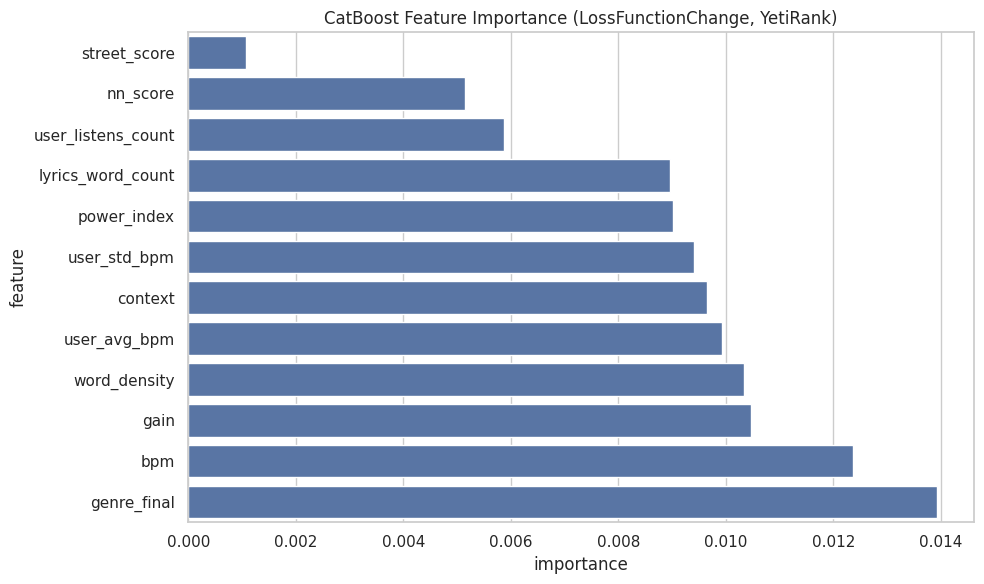

In [11]:
correct_rank_features = ITEM_FEATURES + ['context', 'genre_final', 'nn_score'] + USER_FEATURE_COLS

plt.figure(figsize=(10, 6))
importance = system.ranker.get_feature_importance(data=system.train_pool, type='LossFunctionChange')
importance_df = pd.DataFrame({
    'feature': correct_rank_features,
    'importance': importance
}).sort_values('importance', ascending=True)

sns.barplot(data=importance_df, x='importance', y='feature')
plt.title('CatBoost Feature Importance (LossFunctionChange, YetiRank)')
plt.tight_layout()
plt.show()

#### t-SNE Визуализация

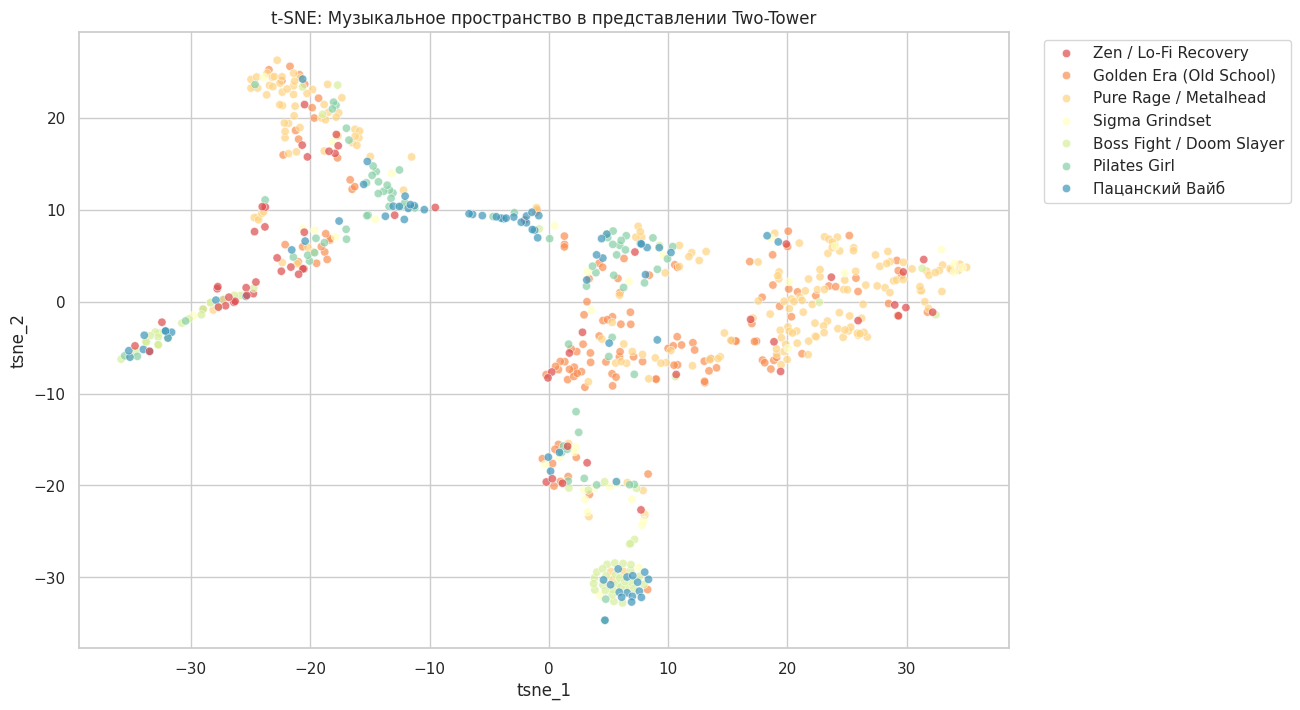

In [12]:
from sklearn.manifold import TSNE

system.model.eval()
with torch.no_grad():
    item_tensor = torch.tensor(system.catalogue[ITEM_FEATURES].to_numpy(dtype='float32'))
    embeddings = system.model.item_tower(item_tensor).numpy()

reduced = TSNE(n_components=2, perplexity=30, random_state=SEED).fit_transform(embeddings)
plot_df = system.catalogue.assign(tsne_1=reduced[:, 0], tsne_2=reduced[:, 1])
plt.figure(figsize=(12, 8))
sns.scatterplot(data=plot_df, x='tsne_1', y='tsne_2', hue='target', palette='Spectral', alpha=.7)
plt.title('t-SNE: Музыкальное пространство в представлении Two-Tower')
plt.legend(bbox_to_anchor=(1.03, 1), loc='upper left')
plt.show()